#0.&nbsp;Initial Setup

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# import os
# default_dir = "Paste_dataset_folder_path_here"
# os.chdir(default_dir)

##0.1. Import Libraries

In [3]:
!pip install catboost

# Data Exploration, Analysis & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

# import statsmodels.api as sm
# import statsmodels.formula.api as smf
# from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy import stats
# from scipy.stats import norm, chi2_contingency
# from sklearn import preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.feature_selection import VarianceThreshold
# from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
# from sklearn import sklearn
from catboost import CatBoostRegressor

# Machine Learning Models and Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import pprint

# Configure Environment
warnings.filterwarnings("ignore")
%matplotlib inline
sns.set(rc={"figure.figsize": (20, 15)})
sns.set_style("whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


##0.2. Load Laptop Price Dataset

In [4]:
# Load Train set
# df = pd.read_csv("assets/laptop_price.csv", encoding='latin1')
# print(f"Train set shape:\n{df.shape}\n")

In [5]:
# Load Train set
df = pd.read_csv("laptop_price.csv", encoding='latin1')
print(f"Train set shape:\n{df.shape}\n")

Train set shape:
(1303, 13)



#1.&nbsp;Data Handling and Cleaning

In [6]:
# Info of each of the variables in our train set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [7]:
# Confirming if there are really no null values
df.isnull().sum()

,0
laptop_ID,0
Company,0
Product,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0


There are no missing values in the dataset.

In [8]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


Drop laptop_ID from the features as it will not be used.

In [9]:
# Store the Id columns before dropping them
ID = df['laptop_ID']

# Drop 'laptop_ID' columns
df = df.drop(columns='laptop_ID')

In [10]:
# Check for duplicates
df.duplicated().sum()

np.int64(28)

There are some duplicates in the dataset. Thus, these need to be dropped

In [11]:
# Dropping the duplicates
df.drop_duplicates(inplace=True)

In [12]:
# Confirming the duplicates drop
df.duplicated().sum()

np.int64(0)

In [13]:
# Initial check of dataset
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [14]:
df["Product"].nunique()

618

The Product feature has an overwhelming amount of unique laptop models. This would only cause the model to overfit. Thus, this feature should be removed from the dataset.

In [15]:
df.drop(columns='Product', inplace=True)

In [16]:
# Checking the unique Laptop types
df['TypeName'].unique()

array(['Ultrabook', 'Notebook', 'Netbook', 'Gaming', '2 in 1 Convertible',
       'Workstation'], dtype=object)

There seems to be no issues with the Laptop types column.

#2.&nbsp;Initial Exploratory Data Analysis

array([[<Axes: title={'center': 'Inches'}>,
        <Axes: title={'center': 'Price_euros'}>]], dtype=object)

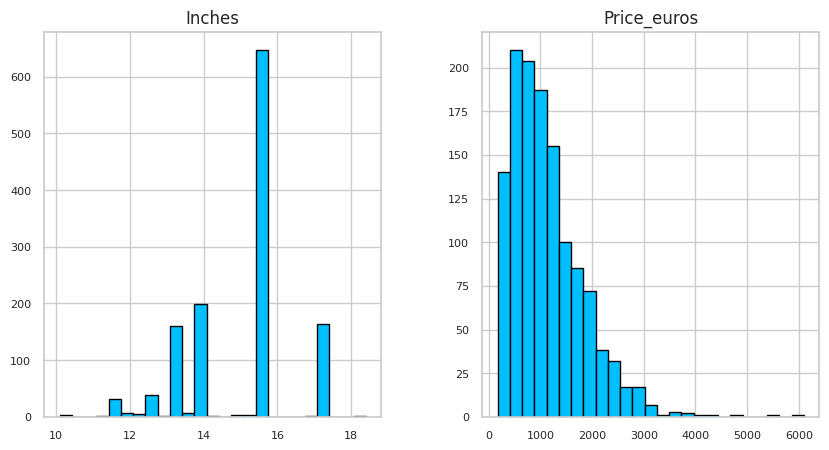

In [17]:
df.hist(
    figsize=(10, 5),
    bins=25,
    color="deepskyblue",
    edgecolor="black",
    xlabelsize=8,
    ylabelsize=8
)

**Insights**
*   Only 1 of the features (Inches) are numerical from the get go.
*   Further exploration of the data is needed to see if any new features can be engineered.
*   Price_euros: Most laptops are priced around 1000 Euros. There are less and less laptops as the Laptop price goes up.

In [18]:
print(f"This is the median of Laptop Prices: {df['Price_euros'].median()}")
print(f"This is the mean of Laptop Prices: {df['Price_euros'].mean()}")

This is the median of Laptop Prices: 989.0
This is the mean of Laptop Prices: 1134.9690588235292


**Insights**
*   It is confirmed that the midrange laptop price is 989 Euros.
*   The average price of laptops are slightly higher though, possibly due to a small amount of laptops being priced over 2000 Euros.

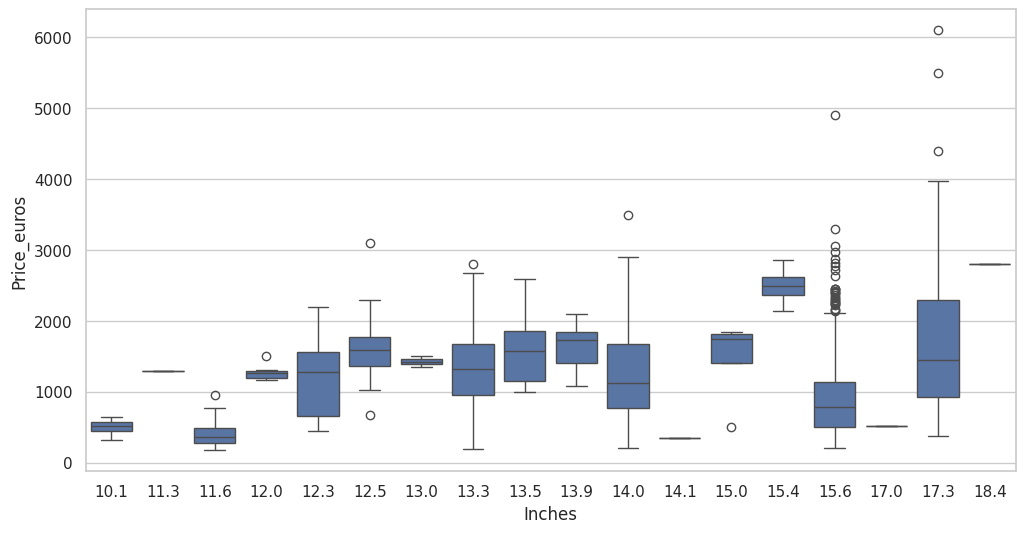

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Inches', y='Price_euros', data=df)
plt.show()

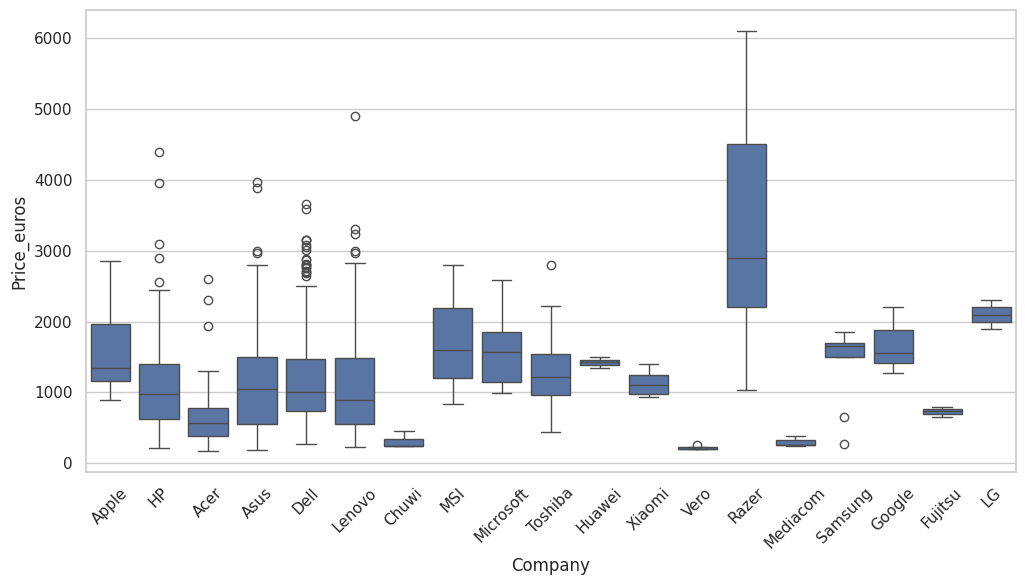

In [20]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Company', y='Price_euros', data=df)
plt.xticks(rotation=45)
plt.show()

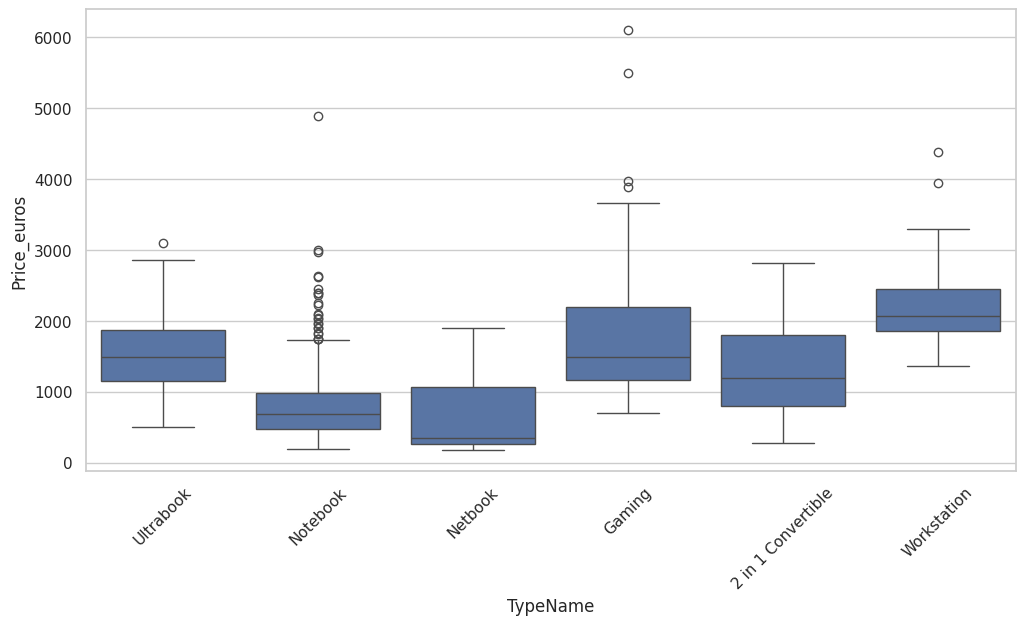

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(x='TypeName', y='Price_euros', data=df)
plt.xticks(rotation=45)
plt.show()

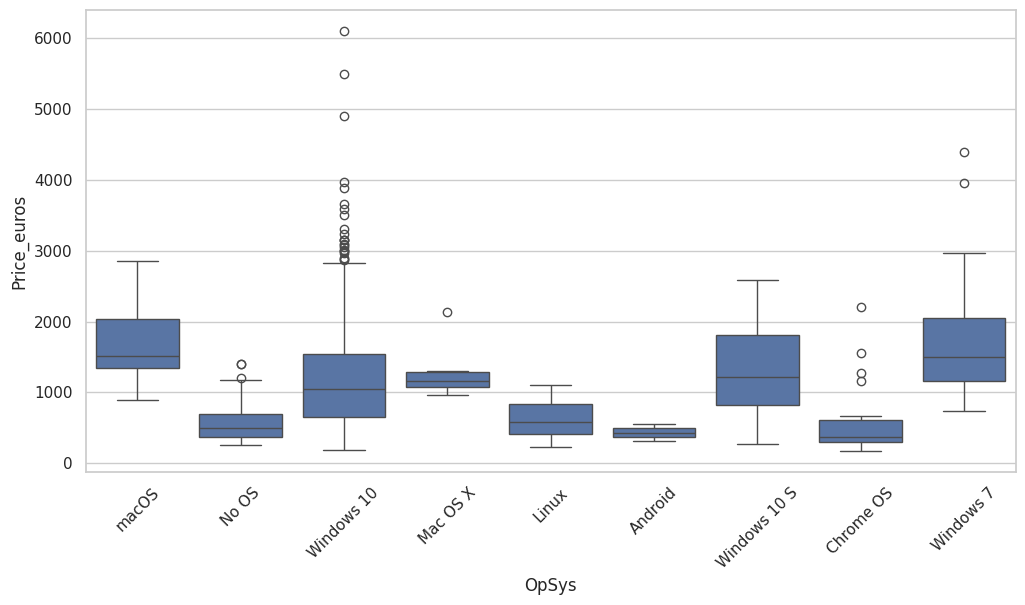

In [22]:
plt.figure(figsize=(12,6))
sns.boxplot(x='OpSys', y='Price_euros', data=df)
plt.xticks(rotation=45)
plt.show()

In [23]:
df["OpSys"].value_counts()

,count
OpSys,
Windows 10,1048
No OS,66
Linux,58
Windows 7,45
Chrome OS,27
macOS,13
Mac OS X,8
Windows 10 S,8
Android,2


Some categories contain very small observations, such as Android, Windows 10 S, Mac OS X, and macOS. Additionally, also validated by the boxplots, the laptop prices of the same Operating System brand e.g. Windows 7, 10 and 10 S are similar to one another. Thus, it would make sense to merge the Operating systems into its respective categories such as Windows, Linux, Mac OS, etc.

#3.&nbsp;Feature Engineering

##3.1. Screen Type & Screen Resolution (X_res & Y_res)
The column ScreenResolution contains both the screen type and screen resolution, which needs to be split into 2 different features. Screen Resolution can then be further split into X_res & Y_res

In [24]:
#Checking unique Screen Resolution values
df['ScreenResolution'].unique()

array(['IPS Panel Retina Display 2560x1600', '1440x900',
       'Full HD 1920x1080', 'IPS Panel Retina Display 2880x1800',
       '1366x768', 'IPS Panel Full HD 1920x1080',
       'IPS Panel Retina Display 2304x1440',
       'IPS Panel Full HD / Touchscreen 1920x1080',
       'Full HD / Touchscreen 1920x1080',
       'Touchscreen / Quad HD+ 3200x1800',
       'IPS Panel Touchscreen 1920x1200', 'Touchscreen 2256x1504',
       'Quad HD+ / Touchscreen 3200x1800', 'IPS Panel 1366x768',
       'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
       'IPS Panel Full HD 2160x1440',
       '4K Ultra HD / Touchscreen 3840x2160', 'Touchscreen 2560x1440',
       '1600x900', 'IPS Panel 4K Ultra HD 3840x2160',
       '4K Ultra HD 3840x2160', 'Touchscreen 1366x768',
       'IPS Panel Full HD 1366x768', 'IPS Panel 2560x1440',
       'IPS Panel Full HD 2560x1440',
       'IPS Panel Retina Display 2736x1824', 'Touchscreen 2400x1600',
       '2560x1440', 'IPS Panel Quad HD+ 2560x1440',
       'IPS Panel 

In [25]:
df[df['ScreenResolution'].str.contains('Retina', case=False)]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
6,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,2139.97
12,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.8GHz,16GB,256GB SSD,AMD Radeon Pro 555,macOS,1.83kg,2439.97
14,Apple,Ultrabook,12.0,IPS Panel Retina Display 2304x1440,Intel Core M m3 1.2GHz,8GB,256GB SSD,Intel HD Graphics 615,macOS,0.92kg,1262.40
15,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,256GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1518.55
17,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16GB,512GB SSD,AMD Radeon Pro 560,macOS,1.83kg,2858.00
45,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.0GHz,8GB,256GB SSD,Intel Iris Graphics 540,macOS,1.37kg,1419.00
81,Apple,Ultrabook,12.0,IPS Panel Retina Display 2304x1440,Intel Core i5 1.3GHz,8GB,512GB SSD,Intel HD Graphics 615,macOS,0.92kg,1510.00


In [26]:
#Function to parse screen types
def screen_type(x):
    # Getting Laptop with Retina Displays
    if 'Retina Display' in x:
        return 'IPS Panel Retina Display'
    # Getting Laptop with IPS Panels
    elif 'IPS Panel' in x:
        return 'IPS Panel'
    # Other Laptops will be defined as 'Standard'
    else:
        return 'Standard'

df['ScreenType'] = df['ScreenResolution'].apply(screen_type)

In [27]:
print('Unique ScreenType values:')
df.groupby('ScreenType').agg({'ScreenResolution': 'count'})

Unique ScreenType values:


,ScreenResolution
ScreenType,
IPS Panel,340
IPS Panel Retina Display,17
Standard,918


In [28]:
# Create 'Touchscreen' column: 1 if 'Touchscreen' is in ScreenResolution, else 0
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)

In [29]:
# Extract the purely numerical resolution part (e.g., "1920x1080")
# This regex specifically captures the last occurrence of "digits x digits" in the string.
ScreenResolution = df['ScreenResolution'].str.extract(r'(\d+x\d+)(?!.*\d+x\d+)')

# Split the extracted resolution into X_res and Y_res for individual analysis
df[['X_res', 'Y_res']] = ScreenResolution[0].str.split('x', expand=True)
df['X_res'] = df['X_res'].astype(int)
df['Y_res'] = df['Y_res'].astype(int)

# Drop the temporary 'Resolution_Only' column as its content is now in 'ScreenResolution'
df = df.drop(columns=['ScreenResolution'])

In [30]:
df.head()

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,ScreenType,Touchscreen,X_res,Y_res
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,IPS Panel Retina Display,0,2560,1600
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,Standard,0,1440,900
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,Standard,0,1920,1080
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,IPS Panel Retina Display,0,2880,1800
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,IPS Panel Retina Display,0,2560,1600


In [31]:
# Display DataFrame info to verify the column has been dropped
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1275 entries, 0 to 1274
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1275 non-null   object 
 1   TypeName     1275 non-null   object 
 2   Inches       1275 non-null   float64
 3   Cpu          1275 non-null   object 
 4   Ram          1275 non-null   object 
 5   Memory       1275 non-null   object 
 6   Gpu          1275 non-null   object 
 7   OpSys        1275 non-null   object 
 8   Weight       1275 non-null   object 
 9   Price_euros  1275 non-null   float64
 10  ScreenType   1275 non-null   object 
 11  Touchscreen  1275 non-null   int64  
 12  X_res        1275 non-null   int64  
 13  Y_res        1275 non-null   int64  
dtypes: float64(2), int64(3), object(9)
memory usage: 149.4+ KB


###3.1.1. Pixels Per Inch (PPI)
Inches and Screen Resolution (X_res & Y_res) can be used to produce Pixels Per Inch (PPI). This is more likely to be more informative.

In [32]:
# The PPI formula
ppi = np.sqrt(
    df['X_res']**2 +
    df['Y_res']**2
) / df['Inches']

# Add ppi value to new column
df['PPI'] = round(ppi, 2)

In [33]:
df.head()

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,ScreenType,Touchscreen,X_res,Y_res,PPI
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,IPS Panel Retina Display,0,2560,1600,226.98
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,Standard,0,1440,900,127.68
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,Standard,0,1920,1080,141.21
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,IPS Panel Retina Display,0,2880,1800,220.53
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,IPS Panel Retina Display,0,2560,1600,226.98


##3.2. Weight & Ram
The Weight and Ram features need to be engineered so that they are recognized as numerical values.

In [34]:
# Remove 'kg' from 'Weight' column and convert to float
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

# Remove 'GB' from 'Ram' column and convert to int
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)

# Checking the data type of the converted Ram column
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1275 entries, 0 to 1274
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1275 non-null   object 
 1   TypeName     1275 non-null   object 
 2   Inches       1275 non-null   float64
 3   Cpu          1275 non-null   object 
 4   Ram          1275 non-null   int64  
 5   Memory       1275 non-null   object 
 6   Gpu          1275 non-null   object 
 7   OpSys        1275 non-null   object 
 8   Weight       1275 non-null   float64
 9   Price_euros  1275 non-null   float64
 10  ScreenType   1275 non-null   object 
 11  Touchscreen  1275 non-null   int64  
 12  X_res        1275 non-null   int64  
 13  Y_res        1275 non-null   int64  
 14  PPI          1275 non-null   float64
dtypes: float64(4), int64(4), object(7)
memory usage: 159.4+ KB


In [35]:
# Checking them in the DataFrame
display(df.head())

,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,ScreenType,Touchscreen,X_res,Y_res,PPI
0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,1339.69,IPS Panel Retina Display,0,2560,1600,226.98
1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,898.94,Standard,0,1440,900,127.68
2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,575.00,Standard,0,1920,1080,141.21
3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,2537.45,IPS Panel Retina Display,0,2880,1800,220.53
4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,1803.60,IPS Panel Retina Display,0,2560,1600,226.98


##3.3. Memory
The Memory feature can contain 2 Memory slots and the type of Memory(s) the laptop has. Thus, it needs to be split into multiple features.

In [36]:
df['Memory'].unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD',
       '32GB Flash Storage', '128GB SSD +  1TB HDD',
       '256GB SSD +  256GB SSD', '64GB Flash Storage',
       '256GB SSD +  1TB HDD', '256GB SSD +  2TB HDD', '32GB SSD',
       '2TB HDD', '64GB SSD', '1.0TB Hybrid', '512GB SSD +  1TB HDD',
       '1TB SSD', '256GB SSD +  500GB HDD', '128GB SSD +  2TB HDD',
       '512GB SSD +  512GB SSD', '16GB SSD', '16GB Flash Storage',
       '512GB SSD +  256GB SSD', '512GB SSD +  2TB HDD',
       '64GB Flash Storage +  1TB HDD', '180GB SSD', '1TB HDD +  1TB HDD',
       '32GB HDD', '1TB SSD +  1TB HDD', '512GB Flash Storage',
       '128GB HDD', '240GB SSD', '8GB SSD', '508GB Hybrid', '1.0TB HDD',
       '512GB SSD +  1.0TB Hybrid', '256GB SSD +  1.0TB Hybrid'],
      dtype=object)

In [37]:
def parse_memory(memory_str):
    ssd = 0
    hdd = 0
    flash_storage = 0
    hybrid = 0

    # Standardize string format and split by '+' to handle multiple storage types
    parts = memory_str.split('+')

    for part in parts:
        part = part.strip() # Remove leading/trailing whitespace
        if 'TB' in part:
            part = part.split(' ')
            part[0] = float(part[0].replace('TB', ''))
            part[0] = part[0] * 1024 # Convert TB to GB
            part[0] = str(part[0]).replace('.0', '') # Replace decimal point with space
            part = " ".join(part)
        else:
          part = part.replace('GB', '') # Remove 'GB'

        if 'SSD' in part:
            size = int(''.join(filter(str.isdigit, part)))
            ssd += size
        elif 'HDD' in part:
            size = int(''.join(filter(str.isdigit, part)))
            hdd += size
        elif 'Flash Storage' in part:
            size = int(''.join(filter(str.isdigit, part)))
            flash_storage += size
        elif 'Hybrid' in part:
            size = int(''.join(filter(str.isdigit, part)))
            hybrid += size

    return pd.Series({'SSD_GB': ssd, 'HDD_GB': hdd, 'Flash_Storage_GB': flash_storage, 'Hybrid_GB': hybrid})

# Apply the function to the 'Memory' column
memory_features = df['Memory'].apply(parse_memory)

# Concatenate the new features with the original DataFrame
df = pd.concat([df, memory_features], axis=1)

# Drop the original 'Memory' column
df = df.drop(columns=['Memory'])

In [38]:
# Checking data types of new columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1275 entries, 0 to 1274
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1275 non-null   object 
 1   TypeName          1275 non-null   object 
 2   Inches            1275 non-null   float64
 3   Cpu               1275 non-null   object 
 4   Ram               1275 non-null   int64  
 5   Gpu               1275 non-null   object 
 6   OpSys             1275 non-null   object 
 7   Weight            1275 non-null   float64
 8   Price_euros       1275 non-null   float64
 9   ScreenType        1275 non-null   object 
 10  Touchscreen       1275 non-null   int64  
 11  X_res             1275 non-null   int64  
 12  Y_res             1275 non-null   int64  
 13  PPI               1275 non-null   float64
 14  SSD_GB            1275 non-null   int64  
 15  HDD_GB            1275 non-null   int64  
 16  Flash_Storage_GB  1275 non-null   int64  
 17  

In [39]:
# Checking whether the laptops with 2 SSDs were succesfully combined/added
df['SSD_GB'].unique()

array([ 128,    0,  256,  512,   32,   64, 1024,   16,  768,  180,  240,
          8])

Some unique SSD amounts are due to laptops that contain more than 1 slot of SSDs e.g. 512GB SSD + 256GB SSD = 768GB SSD.

##3.4. CPU
The CPU feature contains multiple information about the CPU such as the brand, the family, and the clockspeed. It also contains the specific CPU model, but not all rows contain that information. Thus, the CPU is split into 3 features: CPU Brand, CPU family, and CPU Clockspeed.

In [40]:
# Checking the unique CPU models there are in the dataset
df['Cpu'].unique()

array(['Intel Core i5 2.3GHz', 'Intel Core i5 1.8GHz',
       'Intel Core i5 7200U 2.5GHz', 'Intel Core i7 2.7GHz',
       'Intel Core i5 3.1GHz', 'AMD A9-Series 9420 3GHz',
       'Intel Core i7 2.2GHz', 'Intel Core i7 8550U 1.8GHz',
       'Intel Core i5 8250U 1.6GHz', 'Intel Core i3 6006U 2GHz',
       'Intel Core i7 2.8GHz', 'Intel Core M m3 1.2GHz',
       'Intel Core i7 7500U 2.7GHz', 'Intel Core i7 2.9GHz',
       'Intel Core i3 7100U 2.4GHz', 'Intel Atom x5-Z8350 1.44GHz',
       'Intel Core i5 7300HQ 2.5GHz', 'AMD E-Series E2-9000e 1.5GHz',
       'Intel Core i5 1.6GHz', 'Intel Core i7 8650U 1.9GHz',
       'Intel Atom x5-Z8300 1.44GHz', 'AMD E-Series E2-6110 1.5GHz',
       'AMD A6-Series 9220 2.5GHz',
       'Intel Celeron Dual Core N3350 1.1GHz',
       'Intel Core i3 7130U 2.7GHz', 'Intel Core i7 7700HQ 2.8GHz',
       'Intel Core i5 2.0GHz', 'AMD Ryzen 1700 3GHz',
       'Intel Pentium Quad Core N4200 1.1GHz',
       'Intel Atom x5-Z8550 1.44GHz',
       'Intel Celeron Du

In [41]:
def parse_cpu(cpu_str):
  # Splitting the string into a list
  cpu_str = cpu_str.split(' ')

  # Storing the first index of the list as the CPU Brand
  cpu_brand = cpu_str[0]

  # Storing the last index of the list as the CPU Clockspeed
  # Also removing the "GHz" so it is recognized as an integer
  cpu_clockspeed = cpu_str[-1].replace("GHz", "")

  #Deleting the stored indices from the list
  cpu_str = np.delete(cpu_str, 0)
  cpu_str = np.delete(cpu_str, -1)

  # Rejoining the list
  cpu_str = " ".join(cpu_str)

  families = [
        "Celeron Dual Core",
        "Celeron Quad Core",
        "Pentium Dual Core",
        "Pentium Quad Core",
        "Core i3",
        "Core i5",
        "Core i7",
        "Core M",
        "A12-Series",
        "A10-Series",
        "A9-Series",
        "A8-Series",
        "A6-Series",
        "A4-Series",
        "E-Series",
        "Ryzen",
        "Xeon",
        "Atom",
        "FX",
        "Cortex"
    ]

  #Check the CPU family and storing it
  for family in sorted(families, key=len, reverse=True):
        if cpu_str.startswith(family):
            cpu_family = family
            break

  return cpu_brand, cpu_family, cpu_clockspeed

df[['Cpu_Brand', 'Cpu_Family', 'Cpu_Clockspeed']] = df['Cpu'].apply(parse_cpu).apply(pd.Series)

# Dropping the orginal Cpu column
df.drop(columns=['Cpu'], inplace=True)

In [42]:
# Checking the CPU columns
df[['Cpu_Brand', 'Cpu_Family', 'Cpu_Clockspeed']]

,Cpu_Brand,Cpu_Family,Cpu_Clockspeed
0,Intel,Core i5,2.3
1,Intel,Core i5,1.8
2,Intel,Core i5,2.5
3,Intel,Core i7,2.7
4,Intel,Core i5,3.1
...,...,...,...
1270,Intel,Core i7,2.5
1271,Intel,Core i7,2.5
1272,Intel,Celeron Dual Core,1.6
1273,Intel,Core i7,2.5


In [43]:
# Checking the CPU Clockspeed feature data type
print(df["Cpu_Clockspeed"].dtype)

object


In [44]:
# Converting the data type to float
df["Cpu_Clockspeed"] = df["Cpu_Clockspeed"].astype(float)

##3.5. GPU

The orginal GPU feature is preserved. The number of unique GPU categories is manageable, and each GPU name already represented a meaningful hardware configuration.

In [45]:
# Initial Check of the unique GPU values
df['Gpu'].unique()

array(['Intel Iris Plus Graphics 640', 'Intel HD Graphics 6000',
       'Intel HD Graphics 620', 'AMD Radeon Pro 455',
       'Intel Iris Plus Graphics 650', 'AMD Radeon R5',
       'Intel Iris Pro Graphics', 'Nvidia GeForce MX150',
       'Intel UHD Graphics 620', 'Intel HD Graphics 520',
       'AMD Radeon Pro 555', 'AMD Radeon R5 M430',
       'Intel HD Graphics 615', 'AMD Radeon Pro 560',
       'Nvidia GeForce 940MX', 'Intel HD Graphics 400',
       'Nvidia GeForce GTX 1050', 'AMD Radeon R2', 'AMD Radeon 530',
       'Nvidia GeForce 930MX', 'Intel HD Graphics',
       'Intel HD Graphics 500', 'Nvidia GeForce 930MX ',
       'Nvidia GeForce GTX 1060', 'Nvidia GeForce 150MX',
       'Intel Iris Graphics 540', 'AMD Radeon RX 580',
       'Nvidia GeForce 920MX', 'AMD Radeon R4 Graphics', 'AMD Radeon 520',
       'Nvidia GeForce GTX 1070', 'Nvidia GeForce GTX 1050 Ti',
       'Nvidia GeForce MX130', 'AMD R4 Graphics',
       'Nvidia GeForce GTX 940MX', 'AMD Radeon RX 560',
       'Nvid

**Preprocessing Notes:**
*   Need to standardize the GPU Series, specifically "GeForce", since they seem to be the same GPU Model, but the Series varies from "GeForce", "GeForce GTX".
*   Need to standardize the GPU model "Ti" is sometimes entered as "1050 Ti" and "1050Ti", which causes them to be recognized as different GPU models.
*   Need to get rid of unnecessary whitespaces. The Whitespace at the start or end of the Gpu string is going to cause the same GPU to be recognized as different ones.


In [46]:
# Quick check of distribution of the GPU Models
df['Gpu'].value_counts().head(30)

,count
Gpu,
Intel HD Graphics 620,279
Intel HD Graphics 520,181
Intel UHD Graphics 620,68
Nvidia GeForce GTX 1050,66
Nvidia GeForce GTX 1060,48
Nvidia GeForce 940MX,43
AMD Radeon 530,41
Intel HD Graphics 500,39
Intel HD Graphics 400,33


In [47]:
# Checking the number of unique GPU models before standardizing the format
df['Gpu'].nunique()

110

In [48]:
def clean_gpu(gpu):
    # Remove leading/trailing whitespace
    gpu = gpu.strip()

    # Replace multiple spaces with a single space
    gpu = re.sub(r'\s+', ' ', gpu)

    # Standardize GTX formatting
    gpu = re.sub(r'GTX(?=\d)', 'GTX ', gpu)
    gpu = re.sub(r'GT(?=\d)', 'GT ', gpu)
    gpu = re.sub(r'MX(?=\d)', 'MX ', gpu)

    # 1050Ti -> 1050 Ti
    # gpu = re.sub(r'(?<=\d)Ti\b', ' Ti', gpu)

    # Fix encoding issues
    # gpu = gpu.replace('<U+039C>', 'M')

    # Manual corrections
    replacements = {
        # Intel
        'Intel Graphics 620':
            'Intel HD Graphics 620',

        # Nvidia
        'Nvidia GeForce 150MX':
            'Nvidia GeForce MX150',

        'Nvidia GeForce MX 150':
            'Nvidia GeForce MX150',

        'Nvidia GeForce GTX1080':
            'Nvidia GeForce GTX 1080',

        'Nvidia GeForce GTX1060':
            'Nvidia GeForce GTX 1060',

        'Nvidia GeForce GTX1050 Ti':
            'Nvidia GeForce GTX 1050 Ti',

        'Nvidia GeForce GTX 1050Ti':
            'Nvidia GeForce GTX 1050 Ti',

        'Nvidia GeForce 940M':
            'Nvidia GeForce GTX 940M',

        'Nvidia GeForce GTX 960<U+039C>':
            'Nvidia GeForce GTX 960M',

        'Nvidia GeForce 960M':
            'Nvidia GeForce GTX 960M',

        'Nvidia GeForce 930MX':
            'Nvidia GeForce GTX 930MX',

        'Nvidia GeForce 940MX':
            'Nvidia GeForce GTX 940MX',

        # AMD
        'AMD R4 Graphics':
            'AMD Radeon R4 Graphics',

        'AMD Radeon R2':
            'AMD Radeon R2 Graphics',

        'AMD Radeon R3':
            'AMD Radeon R3 Graphics',

        'AMD Radeon R4':
            'AMD Radeon R4 Graphics',

        'AMD Radeon R7':
            'AMD Radeon R7 Graphics',

        'AMD Radeon 520':
            'AMD Radeon R5 520',
    }

    gpu = replacements.get(gpu, gpu)

    return gpu

df["Gpu"] = df["Gpu"].apply(clean_gpu)

In [49]:
# Confirming changes and checking whether there are still
# some duplicates due to formatting inconcisencies
df['Gpu'].unique()

array(['Intel Iris Plus Graphics 640', 'Intel HD Graphics 6000',
       'Intel HD Graphics 620', 'AMD Radeon Pro 455',
       'Intel Iris Plus Graphics 650', 'AMD Radeon R5',
       'Intel Iris Pro Graphics', 'Nvidia GeForce MX150',
       'Intel UHD Graphics 620', 'Intel HD Graphics 520',
       'AMD Radeon Pro 555', 'AMD Radeon R5 M430',
       'Intel HD Graphics 615', 'AMD Radeon Pro 560',
       'Nvidia GeForce GTX 940MX', 'Intel HD Graphics 400',
       'Nvidia GeForce GTX 1050', 'AMD Radeon R2 Graphics',
       'AMD Radeon 530', 'Nvidia GeForce GTX 930MX', 'Intel HD Graphics',
       'Intel HD Graphics 500', 'Nvidia GeForce GTX 1060',
       'Intel Iris Graphics 540', 'AMD Radeon RX 580',
       'Nvidia GeForce 920MX', 'AMD Radeon R4 Graphics',
       'AMD Radeon R5 520', 'Nvidia GeForce GTX 1070',
       'Nvidia GeForce GTX 1050 Ti', 'Nvidia GeForce MX 130',
       'AMD Radeon RX 560', 'Nvidia GeForce 920M', 'AMD Radeon R7 M445',
       'AMD Radeon RX 550', 'Nvidia GeForce GTX 1

In [50]:
# Checking number of unique GPU models after correct formatting
df['Gpu'].nunique()

90

##3.6 Operating Systems

In [51]:
def normalize_opsys(os):
    os = os.strip()

    if os in ["Windows 10", "Windows 7", "Windows 10 S"]:
        return "Windows"

    elif os in ["macOS", "Mac OS X"]:
        return "Mac OS"

    elif os == "Linux":
        return "Linux"

    elif os == "Chrome OS":
        return "Chrome OS"

    elif os == "No OS":
        return "No OS"

    elif os == "Android":
        return "Android"

    else:
        return os

df["OpSys"] = df["OpSys"].apply(normalize_opsys)

In [52]:
df["OpSys"].value_counts()

,count
OpSys,
Windows,1101
No OS,66
Linux,58
Chrome OS,27
Mac OS,21
Android,2


##3.7 Company

In [53]:
company_freq = pd.DataFrame({
    'Frequency': df['Company'].value_counts(),
    'Percentage (%)': round(df['Company'].value_counts(normalize=True) * 100, 2)
})

company_freq

,Frequency,Percentage (%)
Company,,
Dell,291,22.82
Lenovo,289,22.67
HP,268,21.02
Asus,152,11.92
Acer,101,7.92
MSI,54,4.24
Toshiba,48,3.76
Apple,21,1.65
Samsung,9,0.71


In [54]:
df['Company'] = df['Company'].apply(
    lambda x: x if company_freq.loc[x, 'Frequency'] >= 20 else "Other"
)

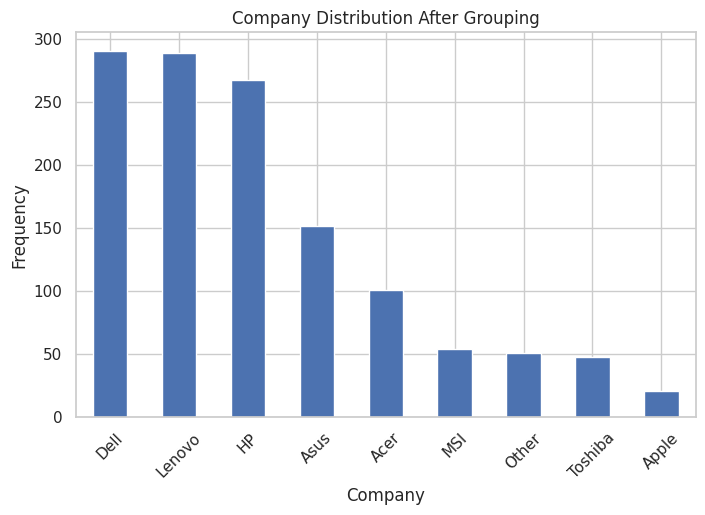

In [55]:
import matplotlib.pyplot as plt

company_after = df['Company'].value_counts()

plt.figure(figsize=(8,5))
company_after.plot(kind='bar')
plt.title("Company Distribution After Grouping")
plt.xlabel("Company")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

#4.&nbsp;Exploratory Data Analysis

##4.1. Numerical Features

array([[<Axes: title={'center': 'Inches'}>,
        <Axes: title={'center': 'Ram'}>,
        <Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Price_euros'}>],
       [<Axes: title={'center': 'Touchscreen'}>,
        <Axes: title={'center': 'X_res'}>,
        <Axes: title={'center': 'Y_res'}>,
        <Axes: title={'center': 'PPI'}>],
       [<Axes: title={'center': 'SSD_GB'}>,
        <Axes: title={'center': 'HDD_GB'}>,
        <Axes: title={'center': 'Flash_Storage_GB'}>,
        <Axes: title={'center': 'Hybrid_GB'}>],
       [<Axes: title={'center': 'Cpu_Clockspeed'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

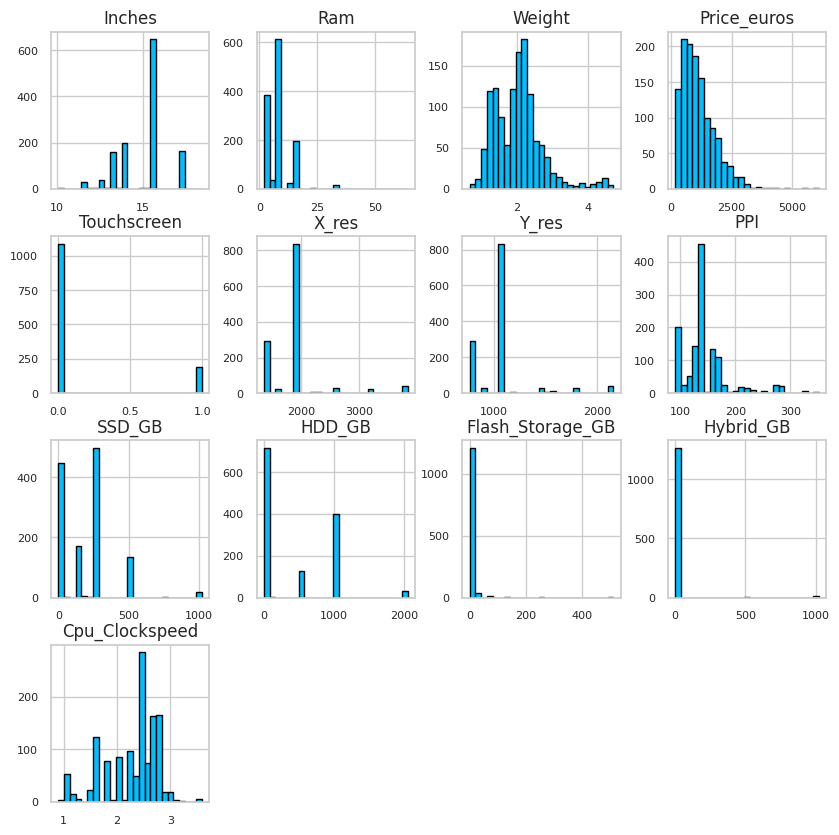

In [56]:
df.hist(
    figsize=(10, 10),
    bins=25,
    color="deepskyblue",
    edgecolor="black",
    xlabelsize=8,
    ylabelsize=8
)

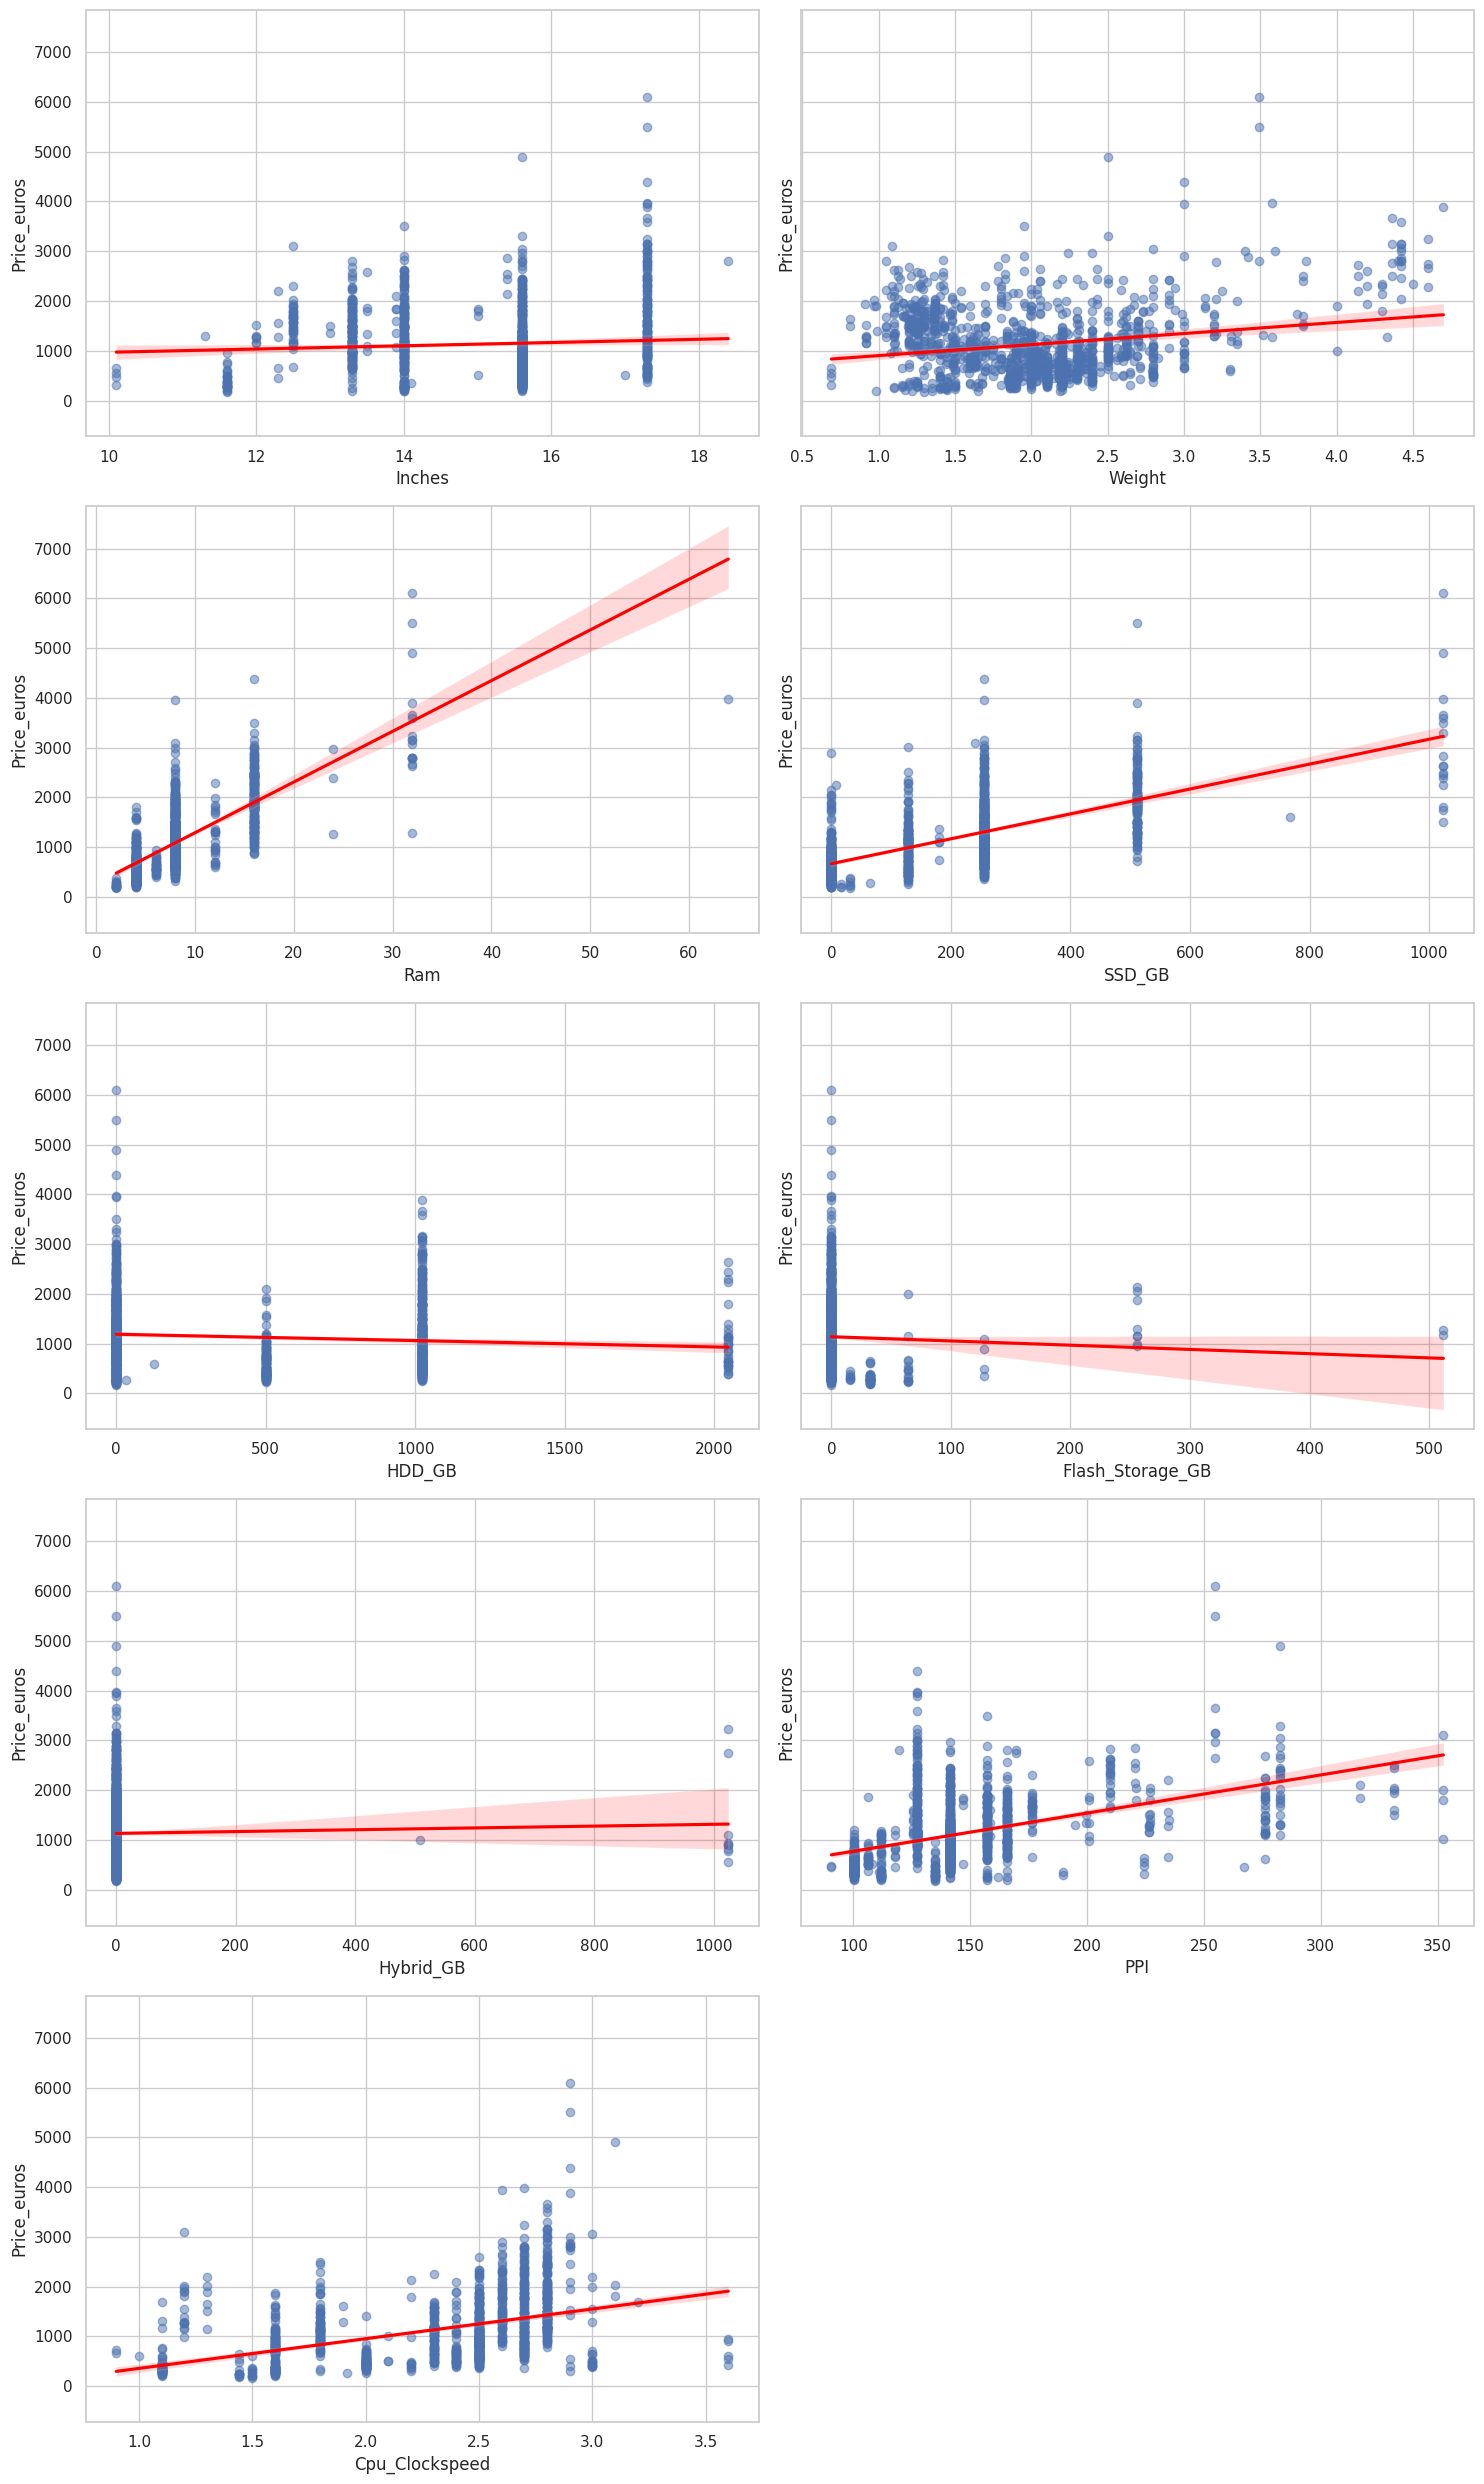

In [57]:
numerical_columns = ['Inches', 'Weight', 'Ram', 'SSD_GB', 'HDD_GB', 'Flash_Storage_GB', 'Hybrid_GB', 'PPI', 'Cpu_Clockspeed']

# Calculate the number of rows and columns for subplots
n_rows = (len(numerical_columns) + 2) // 2  # Ensure enough rows
n_cols = 2

# Creating the subplots
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 5 * n_rows),
    sharey = True
)

# Flatten the axes array for easier iteration
axes = axes.flatten()

for i in range(len(numerical_columns)):
  sns.regplot(
    data=df,
    x=numerical_columns[i],
    y="Price_euros",
    ax=axes[i],
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
  )

# Turn off any unused subplots
for i in range(len(numerical_columns), len(axes)):
    axes[i].set_axis_off()

plt.tight_layout()
plt.show()

##4.2. Categorical Features

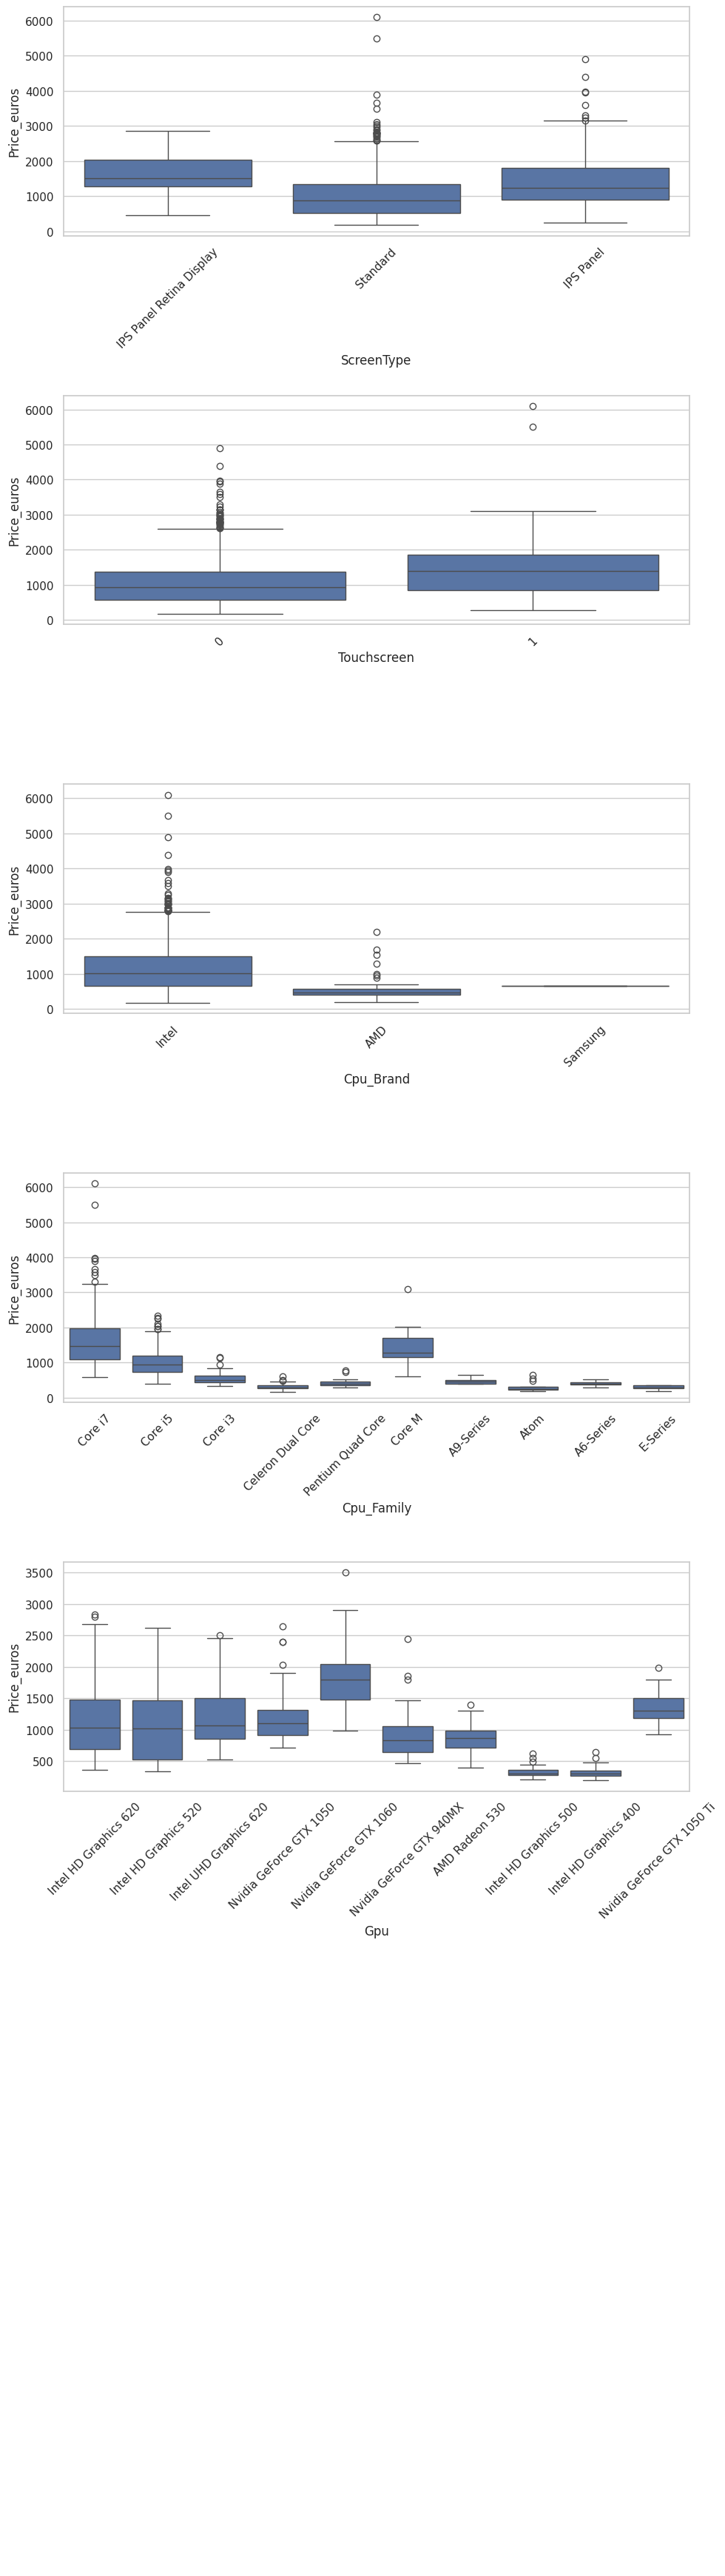

In [58]:
categorical_columns = ['ScreenType', 'Touchscreen','Cpu_Brand', 'Cpu_Family', 'Gpu']

# Calculate the number of rows and columns for subplots
n_rows = (len(categorical_columns) + 2) // 1  # Ensure enough rows
n_cols = 1

# Creating the subplots
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 5 * n_rows),
)

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate through the categorical columns
for i in range(len(categorical_columns)):
  if categorical_columns[i] in ['Cpu_Family', 'Gpu']:
    # Show only the top 10 most common categories in each feature
    top10 = df[categorical_columns[i]].value_counts().head(10).index
    sns.boxplot(
            x=categorical_columns[i],
            y='Price_euros',
            data=df[df[categorical_columns[i]].isin(top10)],
            order=top10,
            ax=axes[i]
        )
  else:
    sns.boxplot(
        x=categorical_columns[i],
        y='Price_euros',
        data=df,
        ax=axes[i],
        )
  axes[i].tick_params(axis='x', rotation=45)

# Turn off any unused subplots
for i in range(len(categorical_columns), len(axes)):
    axes[i].set_axis_off()

plt.tight_layout()
plt.show()

#5.&nbsp;Train Test Split

In [59]:
#Reorder the Price_euros (target) column to be the last column again
price = df.pop("Price_euros")
df["Price_euros"] = price

In [60]:
# Features and target
X = df.drop(columns='Price_euros')
y = df['Price_euros']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1020, 19)
Test set: (255, 19)


#6.&nbsp;Feature Selection

##5.1. Correlation Matrix and Heatmap

In [61]:
# Define the heatmap parameters
pd.options.display.float_format = "{:,.2f}".format

# Define correlation matrix
corr_matrix = df.corr(numeric_only=True)

In [62]:
# Mask the upper part of the heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

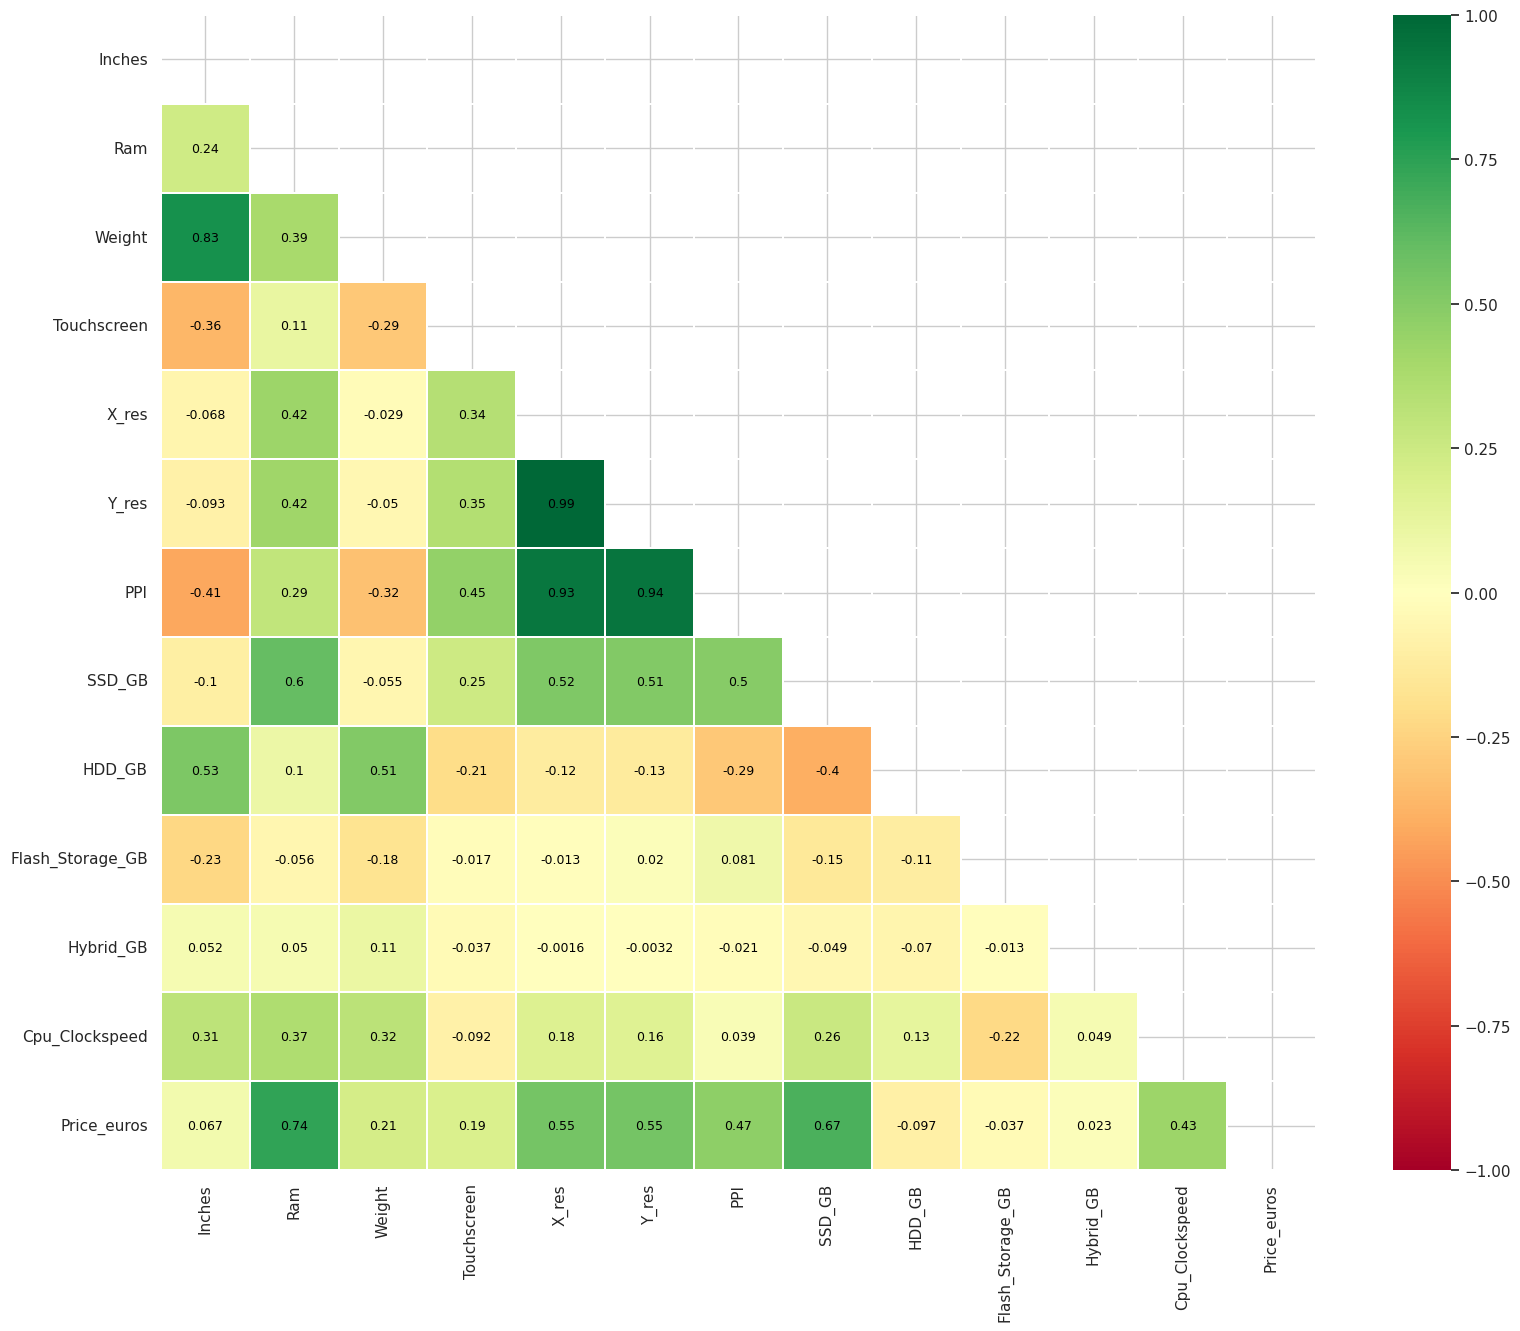

In [63]:
# Choose the color map
cmap = "RdYlGn"

# Plot the heatmap
sns.heatmap(
    data=corr_matrix,
    mask=mask, # cover, not showing them which masked True
    vmax=1.0,
    vmin=-1.0,
    linewidths=0.1,
    annot_kws={
        "size": 9,
        "color": "black"
    },
    square=True,
    cmap=cmap,
    annot=True
);

**Insights**
*   Weight has a strong correlation with Inches. This makes sense as the weight increases when the laptop screen is larger.
*   X_res and Y_res are very strongly correlated. This is natural as they were engineered from the same feature (ScreenResolution)
*   PPI is strongly correlated to both X_res and Y_res, but strangely only moderately correlated to Inches. From this and the previous insights, X_res and Y_res can be removed from the feature set.
*   The target (Price_euros) is strongly correlated to Ram, while also moderately correlated to X_res, Y_res, PPI, and SSD_GB.

In [64]:
X_train = X_train.drop(columns=['X_res', 'Y_res'])
X_test = X_test.drop(columns=['X_res', 'Y_res'])

##5.2. CatBoost

In [65]:
categorical_features_indices = X_train.select_dtypes(include=['object']).columns.tolist()

model = CatBoostRegressor(
    random_seed=42,
    cat_features=categorical_features_indices
)

summary = model.select_features(
    X=X_train,
    y=y_train,
    features_for_select=list(X_train.columns),
    num_features_to_select=13,
    algorithm="RecursiveByShapValues",
    train_final_model=True,
    verbose=True
)

Learning rate set to 0.041071
Step #1 out of 1
0:	learn: 683.8046417	total: 66.1ms	remaining: 1m 6s
1:	learn: 668.3666117	total: 103ms	remaining: 51.6s
2:	learn: 655.4124342	total: 125ms	remaining: 41.5s
3:	learn: 642.1678143	total: 139ms	remaining: 34.5s
4:	learn: 628.1537782	total: 176ms	remaining: 35.1s
5:	learn: 614.7247425	total: 187ms	remaining: 31s
6:	learn: 602.5522627	total: 245ms	remaining: 34.7s
7:	learn: 589.5969210	total: 257ms	remaining: 31.9s
8:	learn: 577.7880494	total: 280ms	remaining: 30.9s
9:	learn: 566.3144896	total: 291ms	remaining: 28.8s
10:	learn: 555.4191703	total: 301ms	remaining: 27.1s
11:	learn: 544.6220300	total: 323ms	remaining: 26.6s
12:	learn: 534.8804101	total: 334ms	remaining: 25.3s
13:	learn: 525.3520314	total: 343ms	remaining: 24.2s
14:	learn: 515.8851266	total: 352ms	remaining: 23.1s
15:	learn: 507.8556162	total: 364ms	remaining: 22.4s
16:	learn: 499.9796666	total: 374ms	remaining: 21.6s
17:	learn: 492.2407388	total: 384ms	remaining: 20.9s
18:	learn:

In [66]:
selected_features = summary["selected_features_names"]

In [67]:
len(X_train.columns.tolist()) - len(summary["selected_features_names"])

4

In [68]:
X_train.columns

Index(['Company', 'TypeName', 'Inches', 'Ram', 'Gpu', 'OpSys', 'Weight',
       'ScreenType', 'Touchscreen', 'PPI', 'SSD_GB', 'HDD_GB',
       'Flash_Storage_GB', 'Hybrid_GB', 'Cpu_Brand', 'Cpu_Family',
       'Cpu_Clockspeed'],
      dtype='object')

In [69]:
set(X_train.columns) - set(summary["selected_features_names"])

{'Flash_Storage_GB', 'HDD_GB', 'Hybrid_GB', 'Touchscreen'}

In [70]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

In [71]:
X_train_selected.columns

Index(['Company', 'TypeName', 'Inches', 'Ram', 'Gpu', 'OpSys', 'Weight',
       'ScreenType', 'PPI', 'SSD_GB', 'Cpu_Brand', 'Cpu_Family',
       'Cpu_Clockspeed'],
      dtype='object')

Manually checked the amount of features that performs best when modelling. After experimenting through 10-15 feature selections, 13 performs the best (avoids overfitting)

#7.&nbsp;Encoding and Standardization

In [72]:
selected_categorical_features = X_train_selected.select_dtypes(include=['object']).columns.tolist()
selected_categorical_features

['Company',
 'TypeName',
 'Gpu',
 'OpSys',
 'ScreenType',
 'Cpu_Brand',
 'Cpu_Family']

All of the remaining fategorical features are nominal features. Thus, OneHotEncoder will be applied to them.

In [73]:
selected_numerical_features = X_train_selected.select_dtypes(exclude=['object']).columns.tolist()
selected_numerical_features

['Inches', 'Ram', 'Weight', 'PPI', 'SSD_GB', 'Cpu_Clockspeed']

In [74]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), selected_numerical_features),          # Numerical column names
        ('cat', OneHotEncoder(handle_unknown='ignore'), selected_categorical_features)   # Categorical column names
    ]
)

#8.&nbsp;Modelling and Evaluation

##8.1. Initial Modelling

In [75]:
# Let's define a function for the evaluation metrics
# Print the scores
def print_score(test, pred):
    """Print calculated score

    Args:
        test -- test data
        pred -- predicted data

    Returns:
        print the regressor name
        print the R squared score
        print Root Mean Square Error score
    """

    print(f"R²: {r2_score(test, pred)}")
    print(f"RMSE: {np.sqrt(mean_squared_error(test, pred))}\n")

In [76]:
# Define regression model pipelines
dtree = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor())
    ])

ridge = Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge())
    ])

lasso = Pipeline([
        ('preprocessor', preprocessor),
        ('model', Lasso(alpha=0.001))
    ])

elasticnet = Pipeline([
        ('preprocessor', preprocessor),
        ('model', ElasticNet(alpha=0.001))
    ])

rf = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor())
    ])

xgb = Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBRegressor())
    ])

lgbm = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LGBMRegressor())
    ])

models = [
    dtree,
    ridge,
    lasso,
    elasticnet,
    rf,
    xgb,
    lgbm
]

# y_train = np.log1p(y_train)

# Train and evaluate each model
for model in models:
    model.fit(X_train_selected, y_train)



    # y_pred = np.expm1(y_pred)

    print(type(model.named_steps['model']).__name__)
    y_pred_train = model.predict(X_train_selected)
    print("Prediction on training dataset Scores")
    print_score(y_train, y_pred_train)
    y_pred = model.predict(X_test_selected)
    print("Prediction on testing dataset Scores")
    print_score(y_test, y_pred)
    print("-" * 50)

DecisionTreeRegressor
Prediction on training dataset Scores
R²: 0.9989890041266892
RMSE: 22.228290847917386

Prediction on testing dataset Scores
R²: 0.778398313576942
RMSE: 331.64683072080885

--------------------------------------------------
Ridge
Prediction on training dataset Scores
R²: 0.8568774185979046
RMSE: 264.47550777286455

Prediction on testing dataset Scores
R²: 0.8326434371037823
RMSE: 288.2110946094975

--------------------------------------------------
Lasso
Prediction on training dataset Scores
R²: 0.8687232058904719
RMSE: 253.29426714499965

Prediction on testing dataset Scores
R²: 0.8089190809403402
RMSE: 307.96260290588276

--------------------------------------------------
ElasticNet
Prediction on training dataset Scores
R²: 0.8630215000682493
RMSE: 258.7364304036655

Prediction on testing dataset Scores
R²: 0.8291318223232765
RMSE: 291.21913980615113

--------------------------------------------------
RandomForestRegressor
Prediction on training dataset Scores
R²

**Evaluation**
*   XGBRegressor was selected for hyperparameter tuning after achieving the highest R² (0.8975) and the lowest RMSE (225.51), while Decision Tree was excluded due to its inferior performance.
*   Decision Tree Regressor showed the weakest performance, with the lowest testing R-Squared and the highest RMSE. Therefore, it was excluded from the hyperparameter tuning process, and XGBRegressor was selected for optimization as it achieved the best overall performance.

##8.2. Hyperparameter Tuning and Optimization


In [83]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid for XGBoost

xgb_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

xgb_grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train_selected, y_train)

# print best params and the corresponding R²
print(f"Best hyperparameters: {xgb_grid_search.best_params_}")
print(f"Best R² (train): {xgb_grid_search.best_score_}")



Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best hyperparameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best R² (train): 0.8420877488540273


In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Get the best estimator (fitted pipeline) directly from GridSearchCV
xgb_mod = xgb

# Predict on test set
y_pred = xgb_mod.predict(X_test_selected)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print("RMSE:", rmse)
print("R2  :", r2)

print(f"- {type(xgb_mod.named_steps['model']).__name__}")
print_score(y_test, y_pred)

MAE: 159.22249737429152
MSE: 50856.53403819703
RMSE: 225.5139331353986
R2  : 0.8975367523319513
- XGBRegressor
R²: 0.8975367523319513
RMSE: 225.5139331353986



In [85]:
model_internal = xgb.named_steps['model']

print(model_internal.get_params())

{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [86]:
import pandas as pd

# Get the feature names after preprocessing
preprocessor_fitted = xgb_mod.named_steps['preprocessor']
transformed_feature_names = preprocessor_fitted.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Importance": model_internal.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                              Feature  Importance
1                            num__Ram        0.13
18             cat__TypeName_Notebook        0.12
127           cat__Cpu_Family_Core i7        0.11
20          cat__TypeName_Workstation        0.08
80   cat__Gpu_Nvidia GeForce GTX 1070        0.05
126           cat__Cpu_Family_Core i5        0.04
41        cat__Gpu_AMD Radeon R7 M445        0.03
48         cat__Gpu_AMD Radeon RX 580        0.02
109                cat__OpSys_Windows        0.02
88   cat__Gpu_Nvidia GeForce GTX 965M        0.02


In [87]:
import joblib

# 1. Pastikan model 'ridge_mod' sudah dilatih (setelah baris ridge_mod.fit)
# 2. Tentukan nama file penyimpanan
model_Hargalaptop = 'XGB_submit.pkl'

# 3. Proses Export (Simpan model ke file)
try:
    joblib.dump(xgb_mod, model_Hargalaptop)
    print(f"Berhasil! Model telah disimpan sebagai: {model_Hargalaptop}")
except NameError:
    print("Error: Variabel 'ridge_mod' tidak ditemukan. Pastikan Anda sudah menjalankan sel pelatihan model.")

Berhasil! Model telah disimpan sebagai: XGB_submit.pkl


In [88]:
import pandas as pd
from google.colab import files

# 1. Konversi data yang sudah diproses ke dalam format DataFrame Pandas
df_unduh = pd.DataFrame(X_train_selected)

# Menambahkan kolom target agar dataset lengkap (fitur + target)
df_unduh['target'] = y_train

# 2. Simpan DataFrame tersebut menjadi file CSV di penyimpanan sementara Colab
harga_laptop_csv = 'dataset_final.csv'
df_unduh.to_csv(harga_laptop_csv, index=False)

# 3. Jalankan perintah untuk memicu pengunduhan otomatis ke browser
files.download(harga_laptop_csv)

print(f"Proses selesai. Silakan cek folder 'Downloads' di komputer Anda untuk file: {harga_laptop_csv}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Proses selesai. Silakan cek folder 'Downloads' di komputer Anda untuk file: dataset_final.csv


In [82]:
import sklearn
print(sklearn.__version__)

1.6.1
